<a href="https://colab.research.google.com/github/mynameisnitya/Federated-LEarning-for-CVD-Prediction/blob/main/01_MIMIC_Exploration_CVD.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Mount Drive for Reading dataset

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# @title
#import zipfile

#zip_path = "/content/drive/MyDrive/MIMIC-III/mimic-iii-clinical-database-1.4.zip"
#extract_path = "/content/drive/MyDrive/MIMIC-III/data"

#with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    #zip_ref.extractall(extract_path)

#LOAD CORE TABLES


In [ ]:

import pandas as pd
import numpy as np

BASE_PATH = "/content/drive/MyDrive/MIMIC-III/data/mimic-iii-clinical-database-1.4/"

# Small tables (safe)

patients = pd.read_csv(BASE_PATH + "PATIENTS.csv.gz")
admissions = pd.read_csv(BASE_PATH + "ADMISSIONS.csv.gz")
diagnoses = pd.read_csv(BASE_PATH + "DIAGNOSES_ICD.csv.gz")
d_icd = pd.read_csv(BASE_PATH + "D_ICD_DIAGNOSES.csv.gz")

print("PATIENTS:", patients.shape)
print("ADMISSIONS:", admissions.shape)
print("DIAGNOSES:", diagnoses.shape)
print("D_ICD:", d_icd.shape)

print("Loaded data")


PATIENTS: (46520, 8)
ADMISSIONS: (58976, 19)
DIAGNOSES: (651047, 5)
D_ICD: (14567, 4)
Loaded data


In [ ]:
patients.head()


,ROW_ID,SUBJECT_ID,GENDER,DOB,DOD,DOD_HOSP,DOD_SSN,EXPIRE_FLAG
0,234,249,F,2075-03-13 00:00:00,NaN,NaN,NaN,0
1,235,250,F,2164-12-27 00:00:00,2188-11-22 00:00:00,2188-11-22 00:00:00,NaN,1
2,236,251,M,2090-03-15 00:00:00,NaN,NaN,NaN,0
3,237,252,M,2078-03-06 00:00:00,NaN,NaN,NaN,0
4,238,253,F,2089-11-26 00:00:00,NaN,NaN,NaN,0


In [ ]:
admissions.head()


,ROW_ID,SUBJECT_ID,HADM_ID,ADMITTIME,DISCHTIME,DEATHTIME,ADMISSION_TYPE,ADMISSION_LOCATION,DISCHARGE_LOCATION,INSURANCE,LANGUAGE,RELIGION,MARITAL_STATUS,ETHNICITY,EDREGTIME,EDOUTTIME,DIAGNOSIS,HOSPITAL_EXPIRE_FLAG,HAS_CHARTEVENTS_DATA
0,21,22,165315,2196-04-09 12:26:00,2196-04-10 15:54:00,NaN,EMERGENCY,EMERGENCY ROOM ADMIT,DISC-TRAN CANCER/CHLDRN H,Private,NaN,UNOBTAINABLE,MARRIED,WHITE,2196-04-09 10:06:00,2196-04-09 13:24:00,BENZODIAZEPINE OVERDOSE,0,1
1,22,23,152223,2153-09-03 07:15:00,2153-09-08 19:10:00,NaN,ELECTIVE,PHYS REFERRAL/NORMAL DELI,HOME HEALTH CARE,Medicare,NaN,CATHOLIC,MARRIED,WHITE,NaN,NaN,CORONARY ARTERY DISEASE\CORONARY ARTERY BYPASS...,0,1
2,23,23,124321,2157-10-18 19:34:00,2157-10-25 14:00:00,NaN,EMERGENCY,TRANSFER FROM HOSP/EXTRAM,HOME HEALTH CARE,Medicare,ENGL,CATHOLIC,MARRIED,WHITE,NaN,NaN,BRAIN MASS,0,1
3,24,24,161859,2139-06-06 16:14:00,2139-06-09 12:48:00,NaN,EMERGENCY,TRANSFER FROM HOSP/EXTRAM,HOME,Private,NaN,PROTESTANT QUAKER,SINGLE,WHITE,NaN,NaN,INTERIOR MYOCARDIAL INFARCTION,0,1
4,25,25,129635,2160-11-02 02:06:00,2160-11-05 14:55:00,NaN,EMERGENCY,EMERGENCY ROOM ADMIT,HOME,Private,NaN,UNOBTAINABLE,MARRIED,WHITE,2160-11-02 01:01:00,2160-11-02 04:27:00,ACUTE CORONARY SYNDROME,0,1


In [ ]:
diagnoses.head()

,ROW_ID,SUBJECT_ID,HADM_ID,SEQ_NUM,ICD9_CODE
0,1297,109,172335,1.0,40301
1,1298,109,172335,2.0,486
2,1299,109,172335,3.0,58281
3,1300,109,172335,4.0,5855
4,1301,109,172335,5.0,4254


## Check for Missing Values

In [ ]:
print("----NULL VALUES---")
print("Patients: \n",patients.isnull().sum())
print("---------------------------------")
print("Admissions: \n",admissions.isnull().sum())
print("---------------------------------")
print("Diagnoses: \n",diagnoses.isnull().sum())

----NULL VALUES---
Patients: 
 ROW_ID             0
SUBJECT_ID         0
GENDER             0
DOB                0
DOD            30761
DOD_HOSP       36546
DOD_SSN        33142
EXPIRE_FLAG        0
dtype: int64
---------------------------------
Admissions: 
 ROW_ID                      0
SUBJECT_ID                  0
HADM_ID                     0
ADMITTIME                   0
DISCHTIME                   0
DEATHTIME               53122
ADMISSION_TYPE              0
ADMISSION_LOCATION          0
DISCHARGE_LOCATION          0
INSURANCE                   0
LANGUAGE                25332
RELIGION                  458
MARITAL_STATUS          10128
ETHNICITY                   0
EDREGTIME               28099
EDOUTTIME               28099
DIAGNOSIS                  25
HOSPITAL_EXPIRE_FLAG        0
HAS_CHARTEVENTS_DATA        0
dtype: int64
---------------------------------
Diagnoses: 
 ROW_ID         0
SUBJECT_ID     0
HADM_ID        0
SEQ_NUM       47
ICD9_CODE     47
dtype: int64


# Statistics

In [ ]:
print("Unique Patients:",
      patients["SUBJECT_ID"].nunique())

print("Unique Admissions:",
      admissions["HADM_ID"].nunique())

Unique Patients: 46520
Unique Admissions: 58976


## CVD Patients

In [ ]:
diagnoses["ICD9_CODE"] = diagnoses[
    "ICD9_CODE"
].astype(str)

cvd = diagnoses[
    diagnoses["ICD9_CODE"].str.match(
        r'^(39|40|41|42|43|44|45)'
    )
]

print(
    "CVD Patients:",
    cvd["SUBJECT_ID"].nunique()
)

CVD Patients: 32503


# Load Lab Events

In [ ]:
labevents = pd.read_csv(
    BASE_PATH + "LABEVENTS.csv.gz",
    usecols=["SUBJECT_ID","ITEMID","VALUENUM"]
)

print(labevents.shape)

(27854055, 3)


## Load Lab Dictionary

In [ ]:
d_labitems = pd.read_csv(
    BASE_PATH + "D_LABITEMS.csv.gz"
)

print(d_labitems.shape)

(753, 6)


 ## Cholesterol Search

In [ ]:
d_labitems[
    d_labitems["LABEL"].str.contains(
        "cholesterol",
        case=False,
        na=False
    )
][["ITEMID","LABEL"]]

,ITEMID,LABEL
126,51472,Cholesterol Crystals
167,50840,"Cholesterol, Ascites"
230,50903,Cholesterol Ratio (Total/HDL)
231,50904,"Cholesterol, HDL"
232,50905,"Cholesterol, LDL, Calculated"
233,50906,"Cholesterol, LDL, Measured"
234,50907,"Cholesterol, Total"
357,51031,"Cholesterol, Body Fluid"
377,51051,"Cholesterol, Pleural"


## Heart Reate Search

In [ ]:
d_items = pd.read_csv(
    BASE_PATH + "D_ITEMS.csv.gz"
)

print(d_items.shape)
d_items[
    d_items["LABEL"].str.contains(
        "heart rate",
        case=False,
        na=False
    )
][["ITEMID","LABEL"]].head(20)

(12487, 10)


,ITEMID,LABEL
475,211,Heart Rate
1897,3494,Lowest Heart Rate
11498,220045,Heart Rate
11499,220046,Heart rate Alarm - High
11500,220047,Heart Rate Alarm - Low


## Search Blood pressure

In [ ]:
d_items[
    d_items["LABEL"].str.contains(
        "systolic",
        case=False,
        na=False
    )
][["ITEMID","LABEL"]].head(20)


,ITEMID,LABEL
295,6,ABP [Systolic]
320,51,Arterial BP [Systolic]
671,442,Manual BP [Systolic]
682,455,NBP [Systolic]
705,480,Orthostat BP sitting [Systolic]
707,482,OrthostatBP standing [Systolic]
709,484,Orthostatic BP lying [Systolic]
715,492,PAP [Systolic]
1437,666,Systolic Unloading
1748,3313,BP Cuff [Systolic]


In [ ]:
d_items[
    d_items["LABEL"].str.contains(
        "diastolic",
        case=False,
        na=False
    )
][["ITEMID","LABEL"]].head(20)

,ITEMID,LABEL
417,153,Diastolic Unloading
4633,8364,ABP [Diastolic]
4637,8368,Arterial BP [Diastolic]
4709,8440,Manual BP [Diastolic]
4710,8441,NBP [Diastolic]
4713,8444,Orthostat BP sitting [Diastolic]
4714,8445,OrthostatBP standing [Diastolic]
4715,8446,Orthostatic BP lying [Diastolic]
4717,8448,PAP [Diastolic]
4759,8502,BP Cuff [Diastolic]


## Feature Extration

## CVD Label
CVD = Cardiovascular disease

In [ ]:
diagnoses["ICD9_CODE"] = (
    diagnoses["ICD9_CODE"]
    .astype(str)
)

cvd_patients = diagnoses[
    diagnoses["ICD9_CODE"]
    .str.match(r'^(39|40|41|42|43|44|45)')
]

labels = (
    cvd_patients
    .groupby("SUBJECT_ID")
    .size()
    .reset_index(name="CVD")
)

labels["CVD"] = 1

print(labels.shape)
labels.head()

(32503, 2)


,SUBJECT_ID,CVD
0,3,1
1,6,1
2,9,1
3,12,1
4,13,1


# Age and Gender

In [ ]:
patients["DOB"] = pd.to_datetime(
    patients["DOB"],
    errors="coerce"
)

admissions["ADMITTIME"] = pd.to_datetime(
    admissions["ADMITTIME"],
    errors="coerce"
)

demo = admissions.merge(
    patients,
    on="SUBJECT_ID"
)

demo["AGE"] = (
    demo["ADMITTIME"].dt.year
    - demo["DOB"].dt.year
)

demo.loc[demo["AGE"] > 89, "AGE"] = 90

demo = demo[
    ["SUBJECT_ID", "AGE", "GENDER"]
]

demo.head()

,SUBJECT_ID,AGE,GENDER
0,22,65,F
1,23,71,M
2,23,75,M
3,24,39,M
4,25,59,M


# Glucose Extraction

In [ ]:
glucose = labevents[
    labevents["ITEMID"] == 50809
]

glucose = (
    glucose.groupby("SUBJECT_ID")
    ["VALUENUM"]
    .mean()
    .reset_index()
)

glucose.columns = [
    "SUBJECT_ID",
    "GLUCOSE"
]

print(glucose.shape)

(24058, 2)


## Cholestrolo Extraction

In [ ]:
cholesterol = labevents[
    labevents["ITEMID"] == 50907
]

cholesterol = (
    cholesterol.groupby("SUBJECT_ID")
    ["VALUENUM"]
    .mean()
    .reset_index()
)

cholesterol.columns = [
    "SUBJECT_ID",
    "CHOLESTEROL"
]

print(cholesterol.shape)

(10480, 2)


In [ ]:
print(labels.shape)
print(demo.shape)
print(glucose.shape)
print(cholesterol.shape)

(10318, 2)
(58976, 3)
(24058, 2)
(10480, 2)


## Extract Vitals

In [ ]:
vital_ids = [220045, 220179, 220180]

chartevents = pd.read_csv(
    BASE_PATH + "CHARTEVENTS.csv.gz",
    usecols=["SUBJECT_ID", "ITEMID", "VALUENUM"],
    chunksize=1000000
)


vital_chunks = []

for chunk in chartevents:
    filtered = chunk[
        chunk["ITEMID"].isin(vital_ids)
    ]
    vital_chunks.append(filtered)

vitals = pd.concat(vital_chunks)

print(vitals.shape)

(5342598, 3)


## Heart Rate /BP Features Extraction

In [ ]:
vitals = vitals.dropna(subset=["VALUENUM"])

vitals = (
    vitals.groupby(
        ["SUBJECT_ID", "ITEMID"]
    )["VALUENUM"]
    .mean()
    .unstack()
)

vitals = vitals.rename(
    columns={
        220045: "HEART_RATE",
        220179: "SYS_BP",
        220180: "DIA_BP"
    }
)

print(vitals.shape)
vitals.head()

(17717, 3)


ITEMID,HEART_RATE,SYS_BP,DIA_BP
SUBJECT_ID,,,
23,76.694444,107.062500,62.187500
34,55.864865,128.055556,59.888889
36,85.586538,127.950000,71.390000
85,106.276596,111.125000,63.687500
107,74.975904,110.776316,50.697368


## Merge

In [ ]:
final_df = demo.copy()

final_df = final_df.merge(
    glucose,
    on="SUBJECT_ID",
    how="left"
)

final_df = final_df.merge(
    cholesterol,
    on="SUBJECT_ID",
    how="left"
)

final_df = final_df.merge(
    vitals,
    on="SUBJECT_ID",
    how="left"
)

final_df = final_df.merge(
    labels,
    on="SUBJECT_ID",
    how="left"
)

final_df["CVD"] = (
    final_df["CVD"]
    .fillna(0)
)

print(final_df.shape)

(58976, 9)


# Data Processing and cleaning

In [ ]:
print( "-"*50,"Dataset Overview:", "-"*50)
print("Dataset Shape:", final_df.shape)
final_df.head()

-------------------------------------------------- Dataset Overview: --------------------------------------------------
Dataset Shape: (58976, 9)


,SUBJECT_ID,AGE,GENDER,GLUCOSE,CHOLESTEROL,HEART_RATE,SYS_BP,DIA_BP,CVD
0,22,65,F,NaN,NaN,NaN,NaN,NaN,1.0
1,23,71,M,116.666667,NaN,76.694444,107.0625,62.1875,1.0
2,23,75,M,116.666667,NaN,76.694444,107.0625,62.1875,1.0
3,24,39,M,NaN,NaN,NaN,NaN,NaN,1.0
4,25,59,M,NaN,NaN,NaN,NaN,NaN,1.0


In [ ]:
print( "-"*50,"Dataset Duplicates:", "-"*50)
duplicates = final_df.duplicated().sum()

print("Duplicate Rows:", duplicates)

-------------------------------------------------- Dataset Duplicates: --------------------------------------------------
Duplicate Rows: 6655


In [ ]:
final_df[
    final_df.duplicated(keep=False)
].head(20)

,SUBJECT_ID,AGE,GENDER,GLUCOSE,CHOLESTEROL,HEART_RATE,SYS_BP,DIA_BP,CVD
12,34,90,M,116.000000,163.0,55.864865,128.055556,59.888889,1.0
13,34,90,M,116.000000,163.0,55.864865,128.055556,59.888889,1.0
15,36,70,M,117.767442,NaN,85.586538,127.950000,71.390000,1.0
16,36,70,M,117.767442,NaN,85.586538,127.950000,71.390000,1.0
23,357,63,M,130.826087,NaN,82.606557,105.107735,57.437673,1.0
24,357,63,M,130.826087,NaN,82.606557,105.107735,57.437673,1.0
25,357,64,M,130.826087,NaN,82.606557,105.107735,57.437673,1.0
26,357,64,M,130.826087,NaN,82.606557,105.107735,57.437673,1.0
32,362,86,F,NaN,NaN,NaN,NaN,NaN,1.0
33,362,86,F,NaN,NaN,NaN,NaN,NaN,1.0


In [ ]:
print(final_df["SUBJECT_ID"].nunique())
print(len(final_df))

46520
58976


In [ ]:
final_df = final_df.drop_duplicates()

print(final_df.shape)

(52321, 9)


In [ ]:
print(final_df["SUBJECT_ID"].nunique())
print(len(final_df))

46520
52321


In [ ]:
print( "-"*50,"Dataset Missing Values:", "-"*50)
missing = final_df.isnull().sum()

missing_percent = (
    missing / len(final_df)
) * 100

missing_table = pd.DataFrame({
    "Missing Values": missing,
    "Percentage": missing_percent
})

missing_table.sort_values(
    by="Percentage",
    ascending=False
)

-------------------------------------------------- Dataset Missing Values: --------------------------------------------------


,Missing Values,Percentage
CHOLESTEROL,38768,74.096443
DIA_BP,31189,59.610864
SYS_BP,31189,59.610864
HEART_RATE,30970,59.192294
GLUCOSE,23476,44.869173
SUBJECT_ID,0,0.000000
GENDER,0,0.000000
AGE,0,0.000000
CVD,0,0.000000


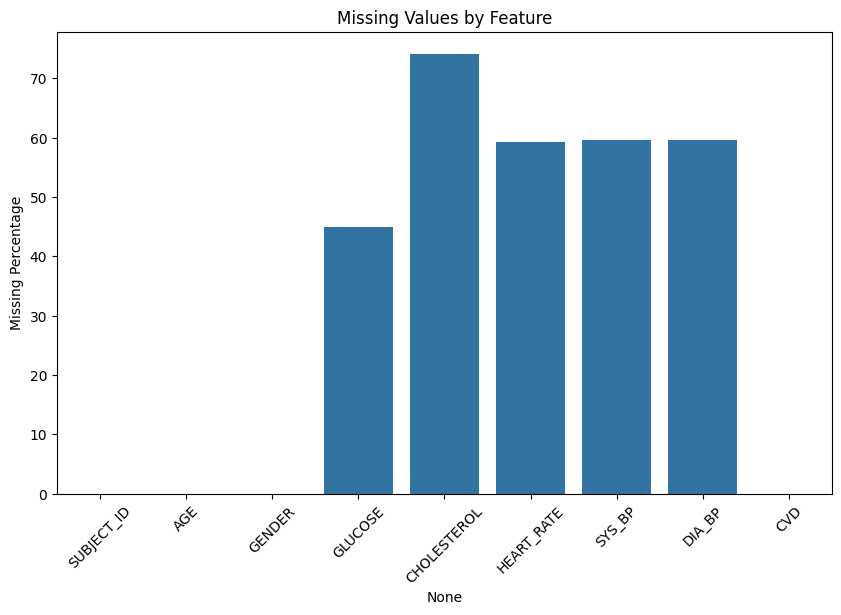

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))

sns.barplot(
    x=missing_table.index,
    y=missing_table["Percentage"]
)

plt.xticks(rotation=45)

plt.ylabel("Missing Percentage")

plt.title(
    "Missing Values by Feature"
)

plt.show()

In [ ]:
final_df

,SUBJECT_ID,AGE,GENDER,GLUCOSE,CHOLESTEROL,HEART_RATE,SYS_BP,DIA_BP,CVD
0,22,65,F,NaN,NaN,NaN,NaN,NaN,1.0
1,23,71,M,116.666667,NaN,76.694444,107.062500,62.187500,1.0
2,23,75,M,116.666667,NaN,76.694444,107.062500,62.187500,1.0
3,24,39,M,NaN,NaN,NaN,NaN,NaN,1.0
4,25,59,M,NaN,NaN,NaN,NaN,NaN,1.0
...,...,...,...,...,...,...,...,...,...
58971,98800,20,F,99.000000,NaN,89.318182,113.850000,57.250000,0.0
58972,98802,84,F,258.000000,NaN,85.461538,152.538462,80.384615,1.0
58973,98805,42,M,130.500000,NaN,113.979167,142.000000,68.000000,0.0
58974,98813,60,F,124.500000,NaN,94.182927,125.451389,67.118056,1.0


In [ ]:
ml_df = final_df[
[
    "AGE",
    "GENDER",
    "GLUCOSE",
    "CHOLESTEROL",
    "HEART_RATE",
    "SYS_BP",
    "DIA_BP",
    "CVD"
]
]

print(ml_df.shape)

print(
    ml_df.dropna().shape
)

(52321, 8)
(4140, 8)


In [ ]:
final_df["GENDER"] = final_df["GENDER"].map({"M":1,"F":0})

In [ ]:
print(
    final_df["GENDER"]
    .value_counts()
)

GENDER
1    29341
0    22980
Name: count, dtype: int64


# Outlier Detection

In [ ]:
numeric_cols = [
    "AGE",
    "GLUCOSE",
    "CHOLESTEROL",
    "HEART_RATE",
    "SYS_BP",
    "DIA_BP"
]

final_df[numeric_cols].describe()

,AGE,GLUCOSE,CHOLESTEROL,HEART_RATE,SYS_BP,DIA_BP
count,52321.000000,28845.000000,13553.000000,21351.000000,21132.000000,21132.000000
mean,54.107032,146.522973,163.512975,85.699871,120.291139,64.378804
std,27.807263,59.458649,49.547938,139.700220,41.124235,31.181922
min,0.000000,15.000000,14.000000,34.714286,45.416667,0.000000
25%,42.000000,117.666667,132.000000,74.913969,108.000000,55.746269
50%,61.000000,134.000000,159.200000,83.760000,117.955051,62.185340
75%,76.000000,157.090909,191.000000,93.359761,129.696875,69.538767
max,90.000000,1349.000000,1285.000000,14447.934003,3122.468936,1818.883023


## Outlier Detection Boxplots

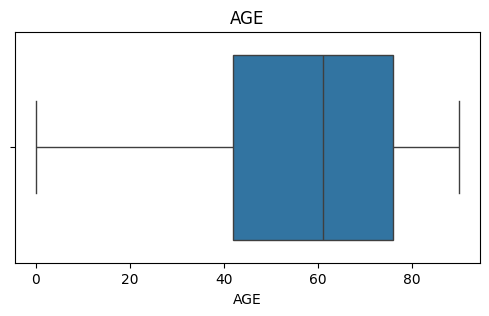

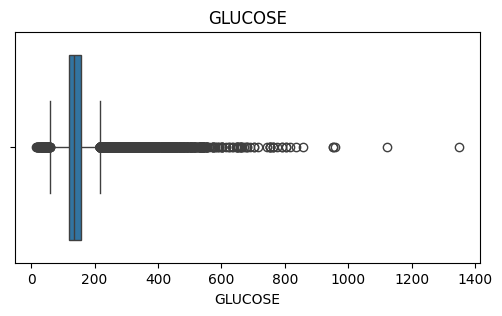

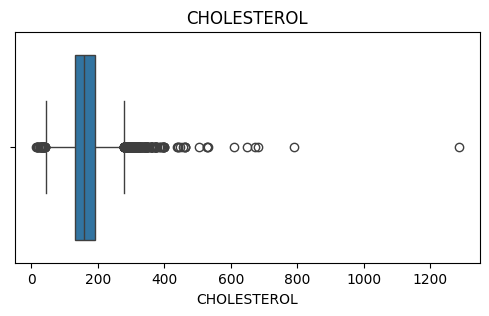

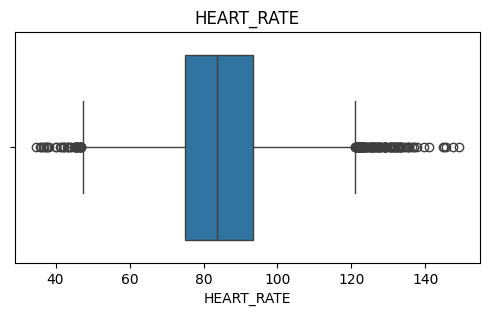

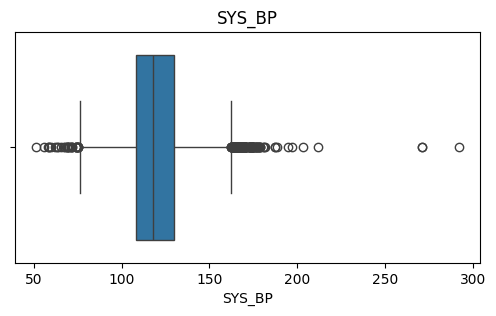

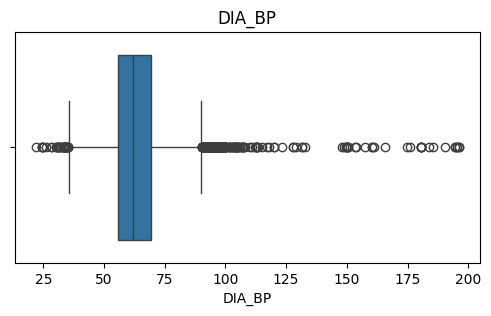

In [ ]:
for col in numeric_cols:

    plt.figure(figsize=(6,3))

    sns.boxplot(
        x=final_df[col]
    )

    plt.title(col)

    plt.show()

# Clinical Range Cleaning

In [ ]:
final_df.loc[
    (final_df["HEART_RATE"] < 20) |
    (final_df["HEART_RATE"] > 250),
    "HEART_RATE"
] = np.nan

final_df.loc[
    (final_df["SYS_BP"] < 50) |
    (final_df["SYS_BP"] > 300),
    "SYS_BP"
] = np.nan

final_df.loc[
    (final_df["DIA_BP"] < 20) |
    (final_df["DIA_BP"] > 200),
    "DIA_BP"
] = np.nan

# Median Imputation

In [ ]:
from sklearn.impute import SimpleImputer

features = [
    "AGE",
    "GENDER",
    "GLUCOSE",
    "CHOLESTEROL",
    "HEART_RATE",
    "SYS_BP",
    "DIA_BP"
]

imputer = SimpleImputer(
    strategy="median"
)

final_df[features] = (
    imputer.fit_transform(
        final_df[features]
    )
)

In [ ]:
print(
    final_df[features]
    .isnull()
    .sum()
)

AGE            0
GENDER         0
GLUCOSE        0
CHOLESTEROL    0
HEART_RATE     0
SYS_BP         0
DIA_BP         0
dtype: int64


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

final_df[features] = (
    scaler.fit_transform(
        final_df[features]
    )
)

In [ ]:
X = final_df[
    [
        "AGE",
        "GENDER",
        "GLUCOSE",
        "CHOLESTEROL",
        "HEART_RATE",
        "SYS_BP",
        "DIA_BP"
    ]
]

y = final_df["CVD"]

print(X.shape)
print(y.shape)

(52321, 7)
(52321,)


# Feature Scaling

In [ ]:
from sklearn.preprocessing import StandardScaler

features = [
    "AGE",
    "GENDER",
    "GLUCOSE",
    "CHOLESTEROL",
    "HEART_RATE",
    "SYS_BP",
    "DIA_BP"
]

scaler = StandardScaler()

final_df[features] = scaler.fit_transform(
    final_df[features]
)

final_df.head()

,SUBJECT_ID,AGE,GENDER,GLUCOSE,CHOLESTEROL,HEART_RATE,SYS_BP,DIA_BP,CVD
0,22,0.391735,-1.129958,-0.154852,-0.044181,-0.027262,-0.065141,-0.056357,1.0
1,23,0.607508,0.884988,-0.543627,-0.044181,-0.842376,-1.121601,-0.051120,1.0
2,23,0.751356,0.884988,-0.543627,-0.044181,-0.842376,-1.121601,-0.051120,1.0
3,24,-0.543282,0.884988,-0.154852,-0.044181,-0.027262,-0.065141,-0.056357,1.0
4,25,0.175962,0.884988,-0.154852,-0.044181,-0.027262,-0.065141,-0.056357,1.0


## Create X and y

In [ ]:
X = final_df[
    [
        "AGE",
        "GENDER",
        "GLUCOSE",
        "CHOLESTEROL",
        "HEART_RATE",
        "SYS_BP",
        "DIA_BP"
    ]
]

y = final_df["CVD"]

print(X.shape)
print(y.shape)

(52321, 7)
(52321,)


# Check Class Balance

In [ ]:
print(y.value_counts())

print(
    y.value_counts(normalize=True)
)

CVD
1.0    38009
0.0    14312
Name: count, dtype: int64
CVD
1.0    0.726458
0.0    0.273542
Name: proportion, dtype: float64


## Train/Test Split

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = (
    train_test_split(
        X,
        y,
        test_size=0.2,
        random_state=42,
        stratify=y
    )
)

print(X_train.shape)
print(X_test.shape)

(41856, 7)
(10465, 7)


## Logistic Regression Baseline

In [ ]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(
    max_iter=1000,
    random_state=42
)

lr.fit(X_train, y_train)

pred_lr = lr.predict(X_test)

# Evaluation

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

prob_lr = lr.predict_proba(X_test)[:,1]

print("Accuracy :", accuracy_score(y_test,pred_lr))
print("Precision:", precision_score(y_test,pred_lr))
print("Recall   :", recall_score(y_test,pred_lr))
print("F1 Score :", f1_score(y_test,pred_lr))
print("AUC      :", roc_auc_score(y_test,prob_lr))



Accuracy : 0.8828475871954132
Precision: 0.8867054827753518
Recall   : 0.9615890555117075
F1 Score : 0.9226303167991923
AUC      : 0.9050668275523207


In [125]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=42,
    class_weight="balanced",
    n_jobs=-1
)

rf.fit(X_train, y_train)

print("Random Forest trained successfully.")

Random Forest trained successfully.


In [126]:
pred_rf = rf.predict(X_test)

prob_rf = rf.predict_proba(X_test)[:,1]

In [127]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report
)

acc_rf = accuracy_score(
    y_test,
    pred_rf
)

prec_rf = precision_score(
    y_test,
    pred_rf
)

rec_rf = recall_score(
    y_test,
    pred_rf
)

f1_rf = f1_score(
    y_test,
    pred_rf
)

auc_rf = roc_auc_score(
    y_test,
    prob_rf
)

print("Accuracy :", acc_rf)
print("Precision:", prec_rf)
print("Recall   :", rec_rf)
print("F1 Score :", f1_rf)
print("AUC      :", auc_rf)

Accuracy : 0.8802675585284281
Precision: 0.9016829052258636
Recall   : 0.9373848987108656
F1 Score : 0.9191873589164785
AUC      : 0.9121456401118039


# Create 5 Hospitals (IID Scenario)

In [ ]:
# IID split

from sklearn.model_selection import train_test_split
import numpy as np

X_train_full, X_test, y_train_full, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

num_clients = 5

client_size = len(X_train_full) // num_clients

client_data = []

for i in range(num_clients):

    start = i * client_size

    if i == num_clients - 1:
        end = len(X_train_full)
    else:
        end = (i + 1) * client_size

    X_client = X_train_full.iloc[start:end]
    y_client = y_train_full.iloc[start:end]

    client_data.append(
        (X_client, y_client)
    )

print("Clients created:", len(client_data))

Clients created: 5


# Neural Network

In [ ]:
import tensorflow as tf

def create_model():

    model = tf.keras.Sequential([

        tf.keras.layers.Dense(
            32,
            activation='relu',
            input_shape=(7,)
        ),

        tf.keras.layers.Dense(
            16,
            activation='relu'
        ),

        tf.keras.layers.Dense(
            1,
            activation='sigmoid'
        )

    ])

    model.compile(

        optimizer=tf.keras.optimizers.Adam(
            learning_rate=0.001
        ),

        loss='binary_crossentropy',

        metrics=[
            'accuracy'
        ]

    )

    return model

# FedAvg Function

In [ ]:
import numpy as np

def federated_average(client_weights):

    avg_weights = []

    for weights in zip(*client_weights):

        avg_weights.append(
            np.mean(weights, axis=0)
        )

    return avg_weights


# Federated Training



In [ ]:
global_model = create_model()

ROUNDS = 50

history_accuracy = []

for round_num in range(ROUNDS):

    print(
        f"\nRound {round_num+1}/{ROUNDS}"
    )

    client_weights = []

    for X_client, y_client in client_data:

        local_model = create_model()

        local_model.set_weights(
            global_model.get_weights()
        )

        local_model.fit(

            X_client,
            y_client,

            epochs=5,
            batch_size=32,

            verbose=0
        )

        client_weights.append(
            local_model.get_weights()
        )

    new_weights = federated_average(
        client_weights
    )

    global_model.set_weights(
        new_weights
    )

    loss, acc = global_model.evaluate(
        X_test,
        y_test,
        verbose=0
    )

    history_accuracy.append(acc)

    print(
        f"Accuracy = {acc:.4f}"
    )

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



Round 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr

Accuracy = 0.8864

Round 2/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr

...

Accuracy = 0.8867

Round 49/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr

Accuracy = 0.8864

Round 50/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr

Accuracy = 0.8865


# Final Evaluation

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

prob_fl = global_model.predict(
    X_test
)

pred_fl = (
    prob_fl > 0.5
).astype(int)

print(
    "Accuracy:",
    accuracy_score(
        y_test,
        pred_fl
    )
)

print(
    "Precision:",
    precision_score(
        y_test,
        pred_fl
    )
)

print(
    "Recall:",
    recall_score(
        y_test,
        pred_fl
    )
)

print(
    "F1:",
    f1_score(
        y_test,
        pred_fl
    )
)

print(
    "AUC:",
    roc_auc_score(
        y_test,
        prob_fl
    )
)

328/328 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
Accuracy: 0.8864787386526517
Precision: 0.8868516284680338
Recall: 0.9671139173901605
F1: 0.9252454064938334
AUC: 0.9156556177699436


# Convergence Graph

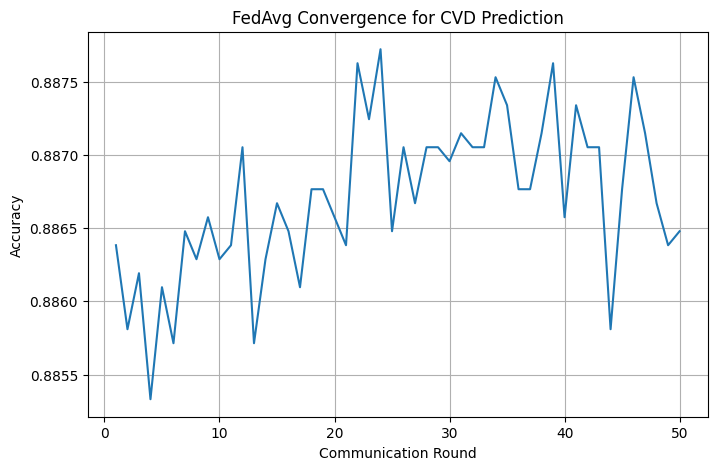

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(
    range(1, ROUNDS+1),
    history_accuracy
)

plt.xlabel(
    "Communication Round"
)

plt.ylabel(
    "Accuracy"
)

plt.title(
    "FedAvg Convergence for CVD Prediction"
)

plt.grid(True)

plt.show()

# Non-IID Federated Learning

In [ ]:
# Separate classes

cvd_patients = final_df[
    final_df["CVD"] == 1
].sample(
    frac=1,
    random_state=42
)

non_cvd_patients = final_df[
    final_df["CVD"] == 0
].sample(
    frac=1,
    random_state=42
)

# Create heterogeneous hospitals

client_1 = pd.concat([
    cvd_patients.iloc[:7000],
    non_cvd_patients.iloc[:1000]
])

client_2 = pd.concat([
    cvd_patients.iloc[7000:14000],
    non_cvd_patients.iloc[1000:2000]
])

client_3 = pd.concat([
    cvd_patients.iloc[14000:19000],
    non_cvd_patients.iloc[2000:7000]
])

client_4 = pd.concat([
    cvd_patients.iloc[19000:22000],
    non_cvd_patients.iloc[7000:12000]
])

client_5 = pd.concat([
    cvd_patients.iloc[22000:25000],
    non_cvd_patients.iloc[12000:]
])

clients_non_iid = [
    client_1,
    client_2,
    client_3,
    client_4,
    client_5
]

for i, client in enumerate(clients_non_iid):

    print(f"\nClient {i+1}")

    print(
        client["CVD"]
        .value_counts(normalize=True)
    )


Client 1
CVD
1.0    0.875
0.0    0.125
Name: proportion, dtype: float64

Client 2
CVD
1.0    0.875
0.0    0.125
Name: proportion, dtype: float64

Client 3
CVD
1.0    0.5
0.0    0.5
Name: proportion, dtype: float64

Client 4
CVD
0.0    0.625
1.0    0.375
Name: proportion, dtype: float64

Client 5
CVD
1.0    0.564759
0.0    0.435241
Name: proportion, dtype: float64


## Test set

In [ ]:
features = [
    "AGE",
    "GENDER",
    "GLUCOSE",
    "CHOLESTEROL",
    "HEART_RATE",
    "SYS_BP",
    "DIA_BP"
]

X_test_np = X_test.values
y_test_np = y_test.values

## Federated Training (Non-IID)

In [ ]:
global_model_noniid = create_model()

ROUNDS = 50

history_accuracy_noniid = []

for round_num in range(ROUNDS):

    print(
        f"Round {round_num+1}/{ROUNDS}"
    )

    client_weights = []

    for client_df in clients_non_iid:

        X_client = client_df[features]

        y_client = client_df["CVD"]

        local_model = create_model()

        local_model.set_weights(
            global_model_noniid.get_weights()
        )

        local_model.fit(
            X_client,
            y_client,
            epochs=5,
            batch_size=32,
            verbose=0
        )

        client_weights.append(
            local_model.get_weights()
        )

    avg_weights = federated_average(
        client_weights
    )

    global_model_noniid.set_weights(
        avg_weights
    )

    loss, acc = global_model_noniid.evaluate(
        X_test_np,
        y_test_np,
        verbose=0
    )

    history_accuracy_noniid.append(acc)

    print(
        f"Accuracy: {acc:.4f}"
    )

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Round 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr

Accuracy: 0.8839
Round 2/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr

...

Accuracy: 0.8871
Round 49/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr

Accuracy: 0.8873
Round 50/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr

Accuracy: 0.8868


## Evaluate Non-IID Model

In [ ]:
prob_noniid = global_model_noniid.predict(
    X_test_np
)

pred_noniid = (
    prob_noniid > 0.5
).astype(int)

from sklearn.metrics import *

print(
    "Accuracy:",
    accuracy_score(
        y_test_np,
        pred_noniid
    )
)

print(
    "Precision:",
    precision_score(
        y_test_np,
        pred_noniid
    )
)

print(
    "Recall:",
    recall_score(
        y_test_np,
        pred_noniid
    )
)

print(
    "F1:",
    f1_score(
        y_test_np,
        pred_noniid
    )
)

print(
    "AUC:",
    roc_auc_score(
        y_test_np,
        prob_noniid
    )
)

328/328 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
Accuracy: 0.8867654085045389
Precision: 0.8964537254417397
Recall: 0.9543541173375427
F1: 0.9244982478496336
AUC: 0.9193232372715124


# Evaluate Non-IID Model

In [ ]:
comparison = pd.DataFrame({

    "Scenario":[
        "IID Federated",
        "Non-IID Federated"
    ],

    "Accuracy":[
        0.8865,
        accuracy_score(
            y_test_np,
            pred_noniid
        )
    ],

    "AUC":[
        0.9157,
        roc_auc_score(
            y_test_np,
            prob_noniid
        )
    ]

})

comparison

,Scenario,Accuracy,AUC
0,IID Federated,0.886500,0.915700
1,Non-IID Federated,0.886765,0.919323


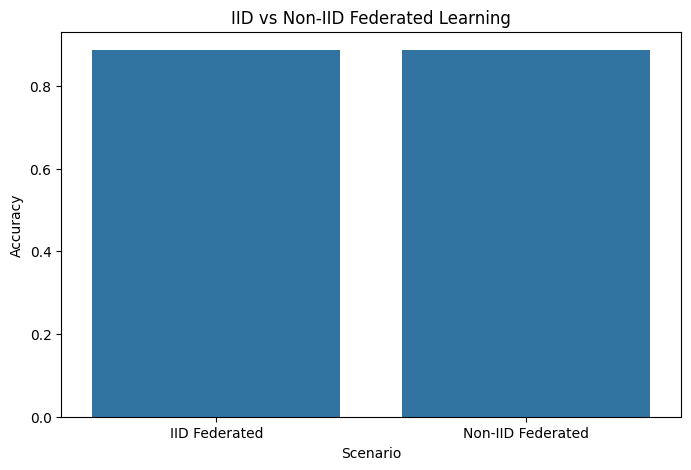

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))

sns.barplot(
    data=comparison,
    x="Scenario",
    y="Accuracy"
)

plt.title(
    "IID vs Non-IID Federated Learning"
)

plt.show()

# Convergence Comparison

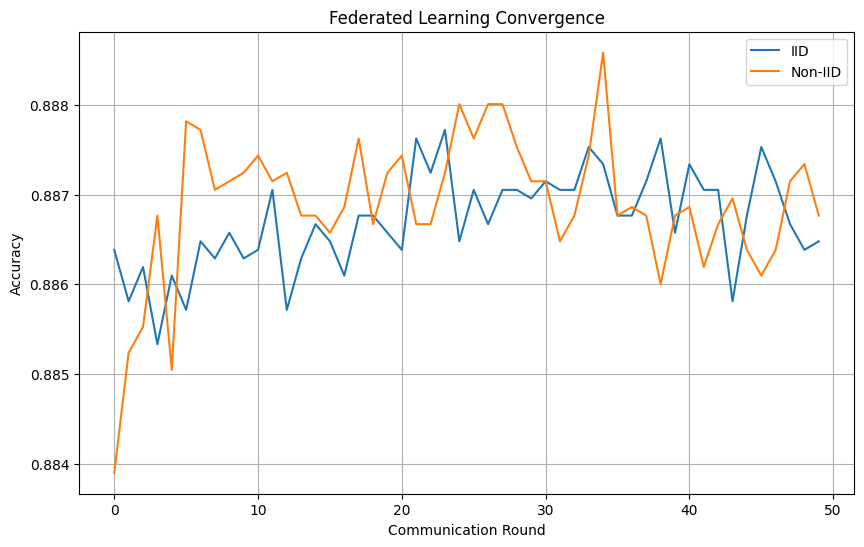

In [ ]:
plt.figure(figsize=(10,6))

plt.plot(
    history_accuracy,
    label="IID"
)

plt.plot(
    history_accuracy_noniid,
    label="Non-IID"
)

plt.xlabel(
    "Communication Round"
)

plt.ylabel(
    "Accuracy"
)

plt.title(
    "Federated Learning Convergence"
)

plt.legend()

plt.grid(True)

plt.show()

# Centralised Neural Network

In [ ]:
central_model = create_model()

history = central_model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=32,
    verbose=1
)

Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1047/1047 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - accuracy: 0.8789 - loss: 0.3194 - val_accuracy: 0.8839 - val_loss: 0.2964
Epoch 2/50
1047/1047 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - accuracy: 0.8891 - loss: 0.2892 - val_accuracy: 0.8843 - val_loss: 0.2948
Epoch 3/50
1047/1047 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - accuracy: 0.8893 - loss: 0.2876 - val_accuracy: 0.8837 - val_loss: 0.2941
Epoch 4/50
1047/1047 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8892 - loss: 0.2867 - val_accuracy: 0.8853 - val_loss: 0.2929
Epoch 5/50
1047/1047 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.8895 - loss: 0.2857 - val_accuracy: 0.8851 - val_loss: 0.2936
Epoch 6/50
1047/1047 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.8901 - loss: 0.2854 - val_accuracy: 0.8850 - val_loss: 0.2921
Epoch 7/50
1047/1047 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.8903 - loss: 0.2850 - val_accuracy: 0.8844 - val_loss: 0.2908
Epoch 8/50
1047/1047 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.8903 - loss: 0.2844 - val_accurac

## Evaluate

In [124]:
prob_central_nn = central_model.predict(X_test)

pred_central_nn = (
    prob_central_nn > 0.5
).astype(int)

print(
    "Accuracy:",
    accuracy_score(
        y_test,
        pred_central_nn
    )
)

print(
    "Precision:",
    precision_score(
        y_test,
        pred_central_nn
    )
)

print(
    "Recall:",
    recall_score(
        y_test,
        pred_central_nn
    )
)

print(
    "F1:",
    f1_score(
        y_test,
        pred_central_nn
    )
)

print(
    "AUC:",
    roc_auc_score(
        y_test,
        prob_central_nn
    )
)



328/328 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
Accuracy: 0.8864787386526517
Precision: 0.8883506902397675
Recall: 0.9650092081031307
F1: 0.9250945775535939
AUC: 0.9146240997851275


# Final Results Table

In [131]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import *

lr = LogisticRegression(
    max_iter=1000,
    random_state=42
)

lr.fit(X_train, y_train)

pred_lr = lr.predict(X_test)
prob_lr = lr.predict_proba(X_test)[:,1]

acc_lr = accuracy_score(y_test,pred_lr)
prec_lr = precision_score(y_test,pred_lr)
rec_lr = recall_score(y_test,pred_lr)
f1_lr = f1_score(y_test,pred_lr)
auc_lr = roc_auc_score(y_test,prob_lr)

print(acc_lr, prec_lr, rec_lr, f1_lr, auc_lr)

0.8828475871954132 0.8867054827753518 0.9615890555117075 0.9226303167991923 0.9050668275523207


In [134]:
acc_lr = accuracy_score(y_test,pred_lr)
acc_cnn =  accuracy_score( y_test,pred_central_nn)
f1_cnn = f1_score(y_test,pred_central_nn)
auc_cnn = roc_auc_score(y_test,prob_central_nn)
f1= f1_score(
        y_test,
        pred_central_nn
    )

results = pd.DataFrame({

    "Model":[
        "Logistic Regression",
        "Random Forest",
        "Centralised Neural Network",
        "Federated NN (IID)",
        "Federated NN (Non-IID)"
    ],

    "Accuracy":[
        acc_lr,
        acc_rf,
        acc_cnn,
        0.8865,
        0.8868
    ],

    "F1":[
        f1_lr,
        f1_rf,
        f1_cnn,
        0.9252,
        0.9245
    ],

    "AUC":[
        auc_lr,
        auc_rf,
        auc_cnn,
        0.9157,
        0.9193
    ]
})

results

,Model,Accuracy,F1,AUC
0,Logistic Regression,0.882848,0.922630,0.905067
1,Random Forest,0.880268,0.919187,0.912146
2,Centralised Neural Network,0.886479,0.925095,0.914624
3,Federated NN (IID),0.886500,0.925200,0.915700
4,Federated NN (Non-IID),0.886800,0.924500,0.919300


# Correlation Heatmap

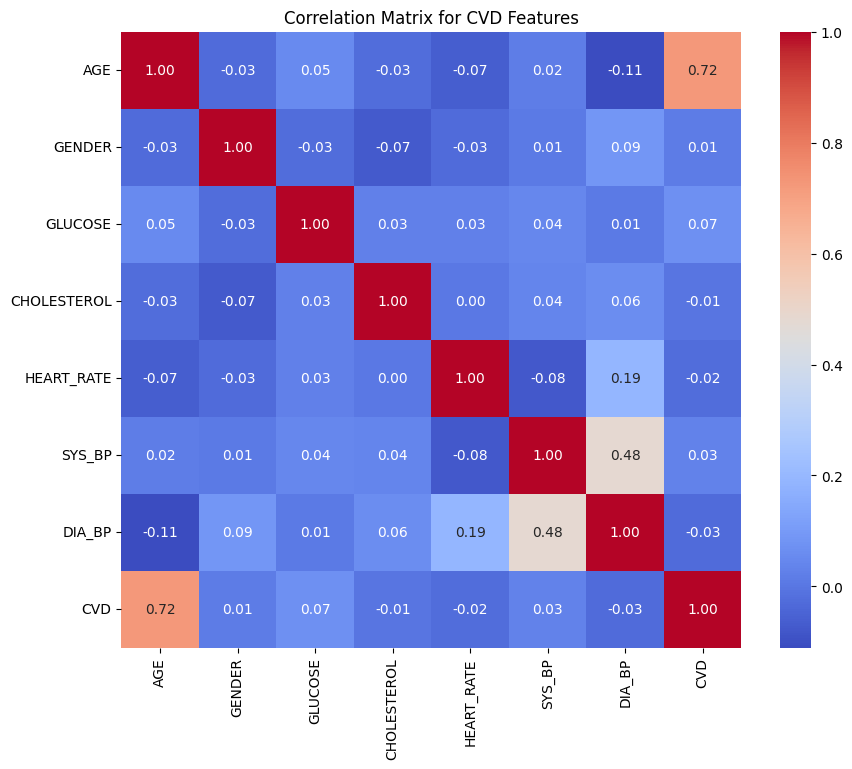

In [135]:
import matplotlib.pyplot as plt
import seaborn as sns

corr_matrix = final_df[
    [
        "AGE",
        "GENDER",
        "GLUCOSE",
        "CHOLESTEROL",
        "HEART_RATE",
        "SYS_BP",
        "DIA_BP",
        "CVD"
    ]
].corr()

plt.figure(figsize=(10,8))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title(
    "Correlation Matrix for CVD Features"
)

plt.show()

In [139]:
print(y.value_counts())


CVD
1.0    38009
0.0    14312
Name: count, dtype: int64
CVD
1.0    38009
0.0    14312
Name: count, dtype: int64


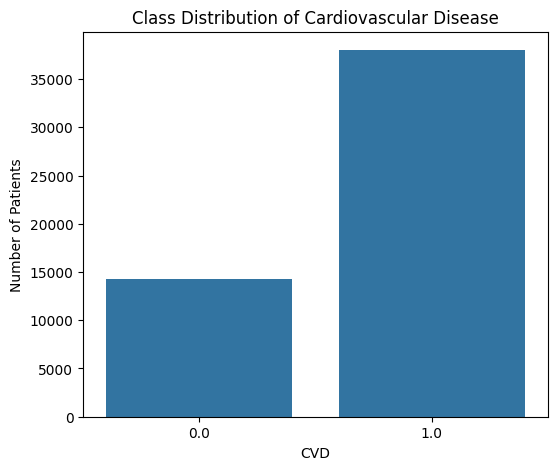

In [140]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,5))

sns.countplot(
    x=final_df["CVD"]
)

plt.title(
    "Class Distribution of Cardiovascular Disease"
)

plt.xlabel("CVD")

plt.ylabel("Number of Patients")

plt.show()

       Feature  Importance
0          AGE    0.526938
2      GLUCOSE    0.181585
3  CHOLESTEROL    0.078455
6       DIA_BP    0.077087
4   HEART_RATE    0.063834
5       SYS_BP    0.061418
1       GENDER    0.010683


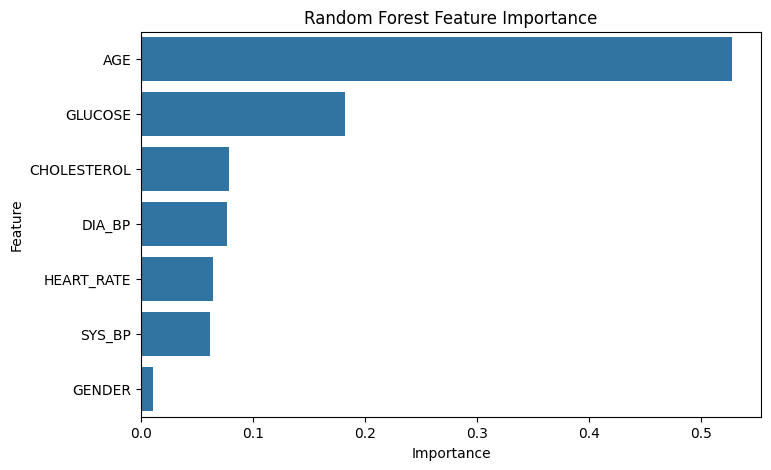

In [141]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

importance = pd.DataFrame({

    "Feature": X.columns,

    "Importance": rf.feature_importances_

})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

print(importance)

plt.figure(figsize=(8,5))

sns.barplot(
    data=importance,
    x="Importance",
    y="Feature"
)

plt.title(
    "Random Forest Feature Importance"
)

plt.show()

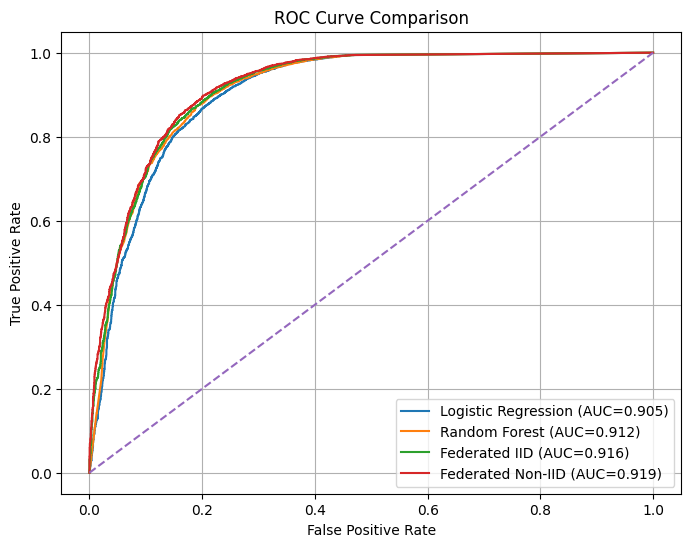

In [142]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

fpr_lr, tpr_lr, _ = roc_curve(
    y_test,
    prob_lr
)

fpr_rf, tpr_rf, _ = roc_curve(
    y_test,
    prob_rf
)

fpr_fl, tpr_fl, _ = roc_curve(
    y_test,
    prob_fl
)

fpr_noniid, tpr_noniid, _ = roc_curve(
    y_test_np,
    prob_noniid
)

plt.figure(figsize=(8,6))

plt.plot(
    fpr_lr,
    tpr_lr,
    label=f"Logistic Regression (AUC={auc_lr:.3f})"
)

plt.plot(
    fpr_rf,
    tpr_rf,
    label=f"Random Forest (AUC={auc_rf:.3f})"
)

plt.plot(
    fpr_fl,
    tpr_fl,
    label=f"Federated IID (AUC={0.9157:.3f})"
)

plt.plot(
    fpr_noniid,
    tpr_noniid,
    label=f"Federated Non-IID (AUC={0.9193:.3f})"
)

plt.plot(
    [0,1],
    [0,1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title(
    "ROC Curve Comparison"
)

plt.legend()

plt.grid(True)

plt.show()

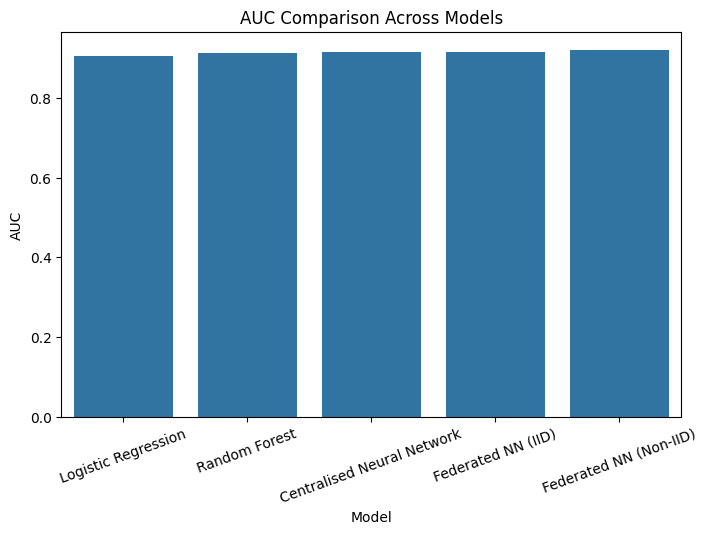

In [143]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=results,
    x="Model",
    y="AUC"
)

plt.xticks(rotation=20)

plt.title(
    "AUC Comparison Across Models"
)

plt.show()

In [144]:
print(final_df.groupby("CVD")["AGE"].describe())

       count      mean       std       min       25%       50%       75%  \
CVD                                                                        
0.0  14312.0 -1.180065  0.935413 -1.945806 -1.945806 -1.945806 -0.363471   
1.0  38009.0  0.444344  0.570353 -1.945806  0.068075  0.499621  0.895205   

          max  
CVD            
0.0  1.290789  
1.0  1.290789  


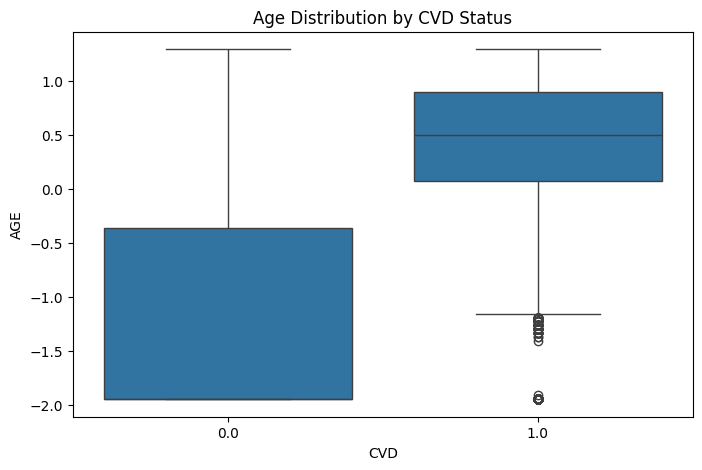

In [145]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x="CVD",
    y="AGE",
    data=final_df
)

plt.title(
    "Age Distribution by CVD Status"
)

plt.show()

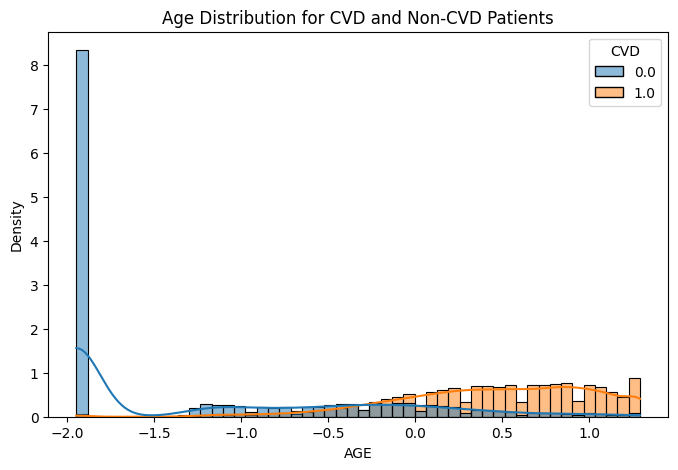

In [146]:
plt.figure(figsize=(8,5))

sns.histplot(
    data=final_df,
    x="AGE",
    hue="CVD",
    kde=True,
    stat="density",
    common_norm=False
)

plt.title(
    "Age Distribution for CVD and Non-CVD Patients"
)

plt.show()

In [147]:
print(importance)

       Feature  Importance
0          AGE    0.526938
2      GLUCOSE    0.181585
3  CHOLESTEROL    0.078455
6       DIA_BP    0.077087
4   HEART_RATE    0.063834
5       SYS_BP    0.061418
1       GENDER    0.010683
